<h1 align="center"> Image Captioning</h1>

![img](https://i.imgur.com/obITaMl.png)


#### План работы:

1. Использовать предобученную модель Inception v3 для преобразования изображений в векторы.

2. Добавить поверх неё LSTM.

3. Обучить модель на датасете [MSCOCO](http://cocodataset.org/#download).

### 1. Данные

In [ ]:
%%time
# Read Dataset
import numpy as np
import json


captions = json.load(open('data/captions_tokenized.json'))
img_codes = np.load("data/image_codes.npy")


Уже преобразованные все изображения из MSCOCO17 в векторы с помощью предобученной сети Inception_v3 из библиотеки [torchvision](https://github.com/pytorch/vision/blob/master/torchvision/models/inception.py).

In [ ]:
print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


Как видно, все подписи уже токенизированы и приведены к нижнему регистру. Теперь нам нужно разделить их и добавить специальные токены, обозначающие начало и конец подписи.

In [ ]:
#split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i]
        captions[img_i][caption_i] = ["#START#"]+sentence.split(' ')+["#END#"]


Посчёт частот слов

In [ ]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()

# Compute word frequencies for each word in captions. See code above for data structure
for img_captions in captions:
    for caption in img_captions:
        word_counts.update(caption)


In [ ]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [ ]:
eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))

    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [ ]:
#try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]], dtype=int32)

### 2. Построение нейронной сети

RNN-модель для генерации текста, которая будет зависеть от векторов, полученных из CNN-части сети.

![img](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)

Во время обучения используются уже готовые вектора-признаков, а сеть Inception добавлена на этапе инференса.


In [ ]:
import torch, torch.nn as nn
import torch.nn.functional as F

In [ ]:
class CaptionNet(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=128, lstm_units=256, cnn_feature_size=2048):
        """ A recurrent 'head' network for image captioning. See scheme above. """
        super(self.__class__, self).__init__()

        # a layer that converts conv features to
        self.cnn_to_h0 = nn.Linear(cnn_feature_size, lstm_units)
        self.cnn_to_c0 = nn.Linear(cnn_feature_size, lstm_units)

        self.emb = nn.Embedding(n_tokens, emb_size)
        self.lstm = nn.LSTM(emb_size, lstm_units, batch_first=True)
        self.logits = nn.Linear(lstm_units, n_tokens)

    def forward(self, image_vectors, captions_ix):
        """
        Apply the network in training mode.
        :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
        :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
            padded with pad_ix
        :returns: logits for next token at each tick, shape: [batch, word_i, n_tokens]
        """
        initial_cell = self.cnn_to_c0(image_vectors)
        initial_hid = self.cnn_to_h0(image_vectors)

        # compute embeddings for captions_ix
        captions_emb = self.emb(captions_ix)

        # lstm_out should be lstm hidden state sequence of shape [batch, caption_length, lstm_units]
        lstm_out, _ = self.lstm(captions_emb, (initial_hid.unsqueeze(0), initial_cell.unsqueeze(0)))
        logits = self.logits(lstm_out)

        return logits

In [ ]:
network = CaptionNet(n_tokens)

In [ ]:
dummy_img_vec = torch.randn(len(captions[0]), 2048)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [ ]:
def compute_loss(network, image_vectors, captions_ix):
    """
    :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
    :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
        padded with pad_ix
    :returns: scalar crossentropy loss (neg llh) loss for next captions_ix given previous ones
    """

    # captions for input - all except last cuz we don't know next token for last one.
    captions_ix_inp = captions_ix[:, :-1].contiguous()
    captions_ix_next = captions_ix[:, 1:].contiguous()

    # apply the network, get predictions for captions_ix_next
    logits_for_next = network.forward(image_vectors, captions_ix_inp)

    loss = F.cross_entropy(
        logits_for_next.view(-1, n_tokens),
        captions_ix_next.view(-1),
        ignore_index=pad_ix,
        ).reshape(1)

    return loss


In [ ]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix)

assert dummy_loss.shape == torch.Size([1]), 'loss must be scalar'
assert dummy_loss.data.numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
        'loss should depend differentiably on all neural network weights'

In [ ]:
optimizer = torch.optim.Adam(network.parameters(), lr=0.0012)
LRshed = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 10, gamma = 0.9)

### 3. Обучение

In [ ]:
from sklearn.model_selection import train_test_split
captions = np.array(captions, dtype = object)
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(img_codes, captions,
                                                                                test_size=0.1,
                                                                                random_state=42)

In [ ]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):

    #sample random numbers for image/caption indicies
    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)

    #get images
    batch_images = img_codes[random_image_ix]

    #5-7 captions for each image
    captions_for_batch_images = captions[random_image_ix]

    #pick one from a set of captions for each image
    batch_captions = list(map(choice,captions_for_batch_images))

    #convert to matrix
    batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

    return torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)


In [ ]:
generate_batch(img_codes,captions,3)

(tensor([[0.0468, 0.0725, 0.4465,  ..., 0.3650, 0.7537, 0.2413],
         [1.2044, 0.1280, 0.2344,  ..., 0.0648, 0.4577, 0.2310],
         [0.6478, 0.0908, 0.5097,  ..., 0.2694, 0.6056, 0.1223]]),
 tensor([[   1,   24,   29,   63,   41,    6,   45,  209,   78,  210, 1432,   12,
             2],
         [   1,   45, 1573,  357,   14,   45,    0, 7137,   41,  144,   12,    2,
             3],
         [   1,   24,  106,   14,  149,  148,  193,  117,  108,  109,   12,    2,
             3]]))

Обучайте модель на мини-батчах, как обычно. Периодически проверяйте качество на валидационном наборе.

#### **Советы**

* Если тренировочный лосс почти равен нулю или модель генерирует бессмысленный текст — проверьте, что вы предсказываете следующее слово, а не текущее или слово через два шага.

* Если модель создаёт плавные, но нерелевантные описания:

  * возможно, рекуррентная сеть не получает векторы изображения;

  * также это может быть следствием взрыва градиентов — попробуйте клиппинг или перезапуск обучения;

  * наконец, возможно, модель просто нужно обучить дольше.

* Кросс-энтропия — слабый показатель переобучения:

  * модель может переобучиться по валидационной кросс-энтропии, но при этом продолжать улучшать качество генерации;

  * используйте ручную оценку или автоматические метрики, такие как CIDEr или BLEU.

* Рекомендуется периодически проверять сеть с помощью блока “apply trained model” — можно остановить обучение, протестировать несколько примеров и продолжить.

* Типичные значения функции потерь: около 3–5, если усреднять по времени,
или масштабировать по длине при суммировании. Разумные подписи начинают появляться при лоссе 2.8–3.0.

In [ ]:
batch_size = 50
n_epochs = 40
n_batches_per_epoch = 100
n_validation_batches = 20

In [ ]:
from tqdm import tqdm

for epoch in range(n_epochs):

    train_loss=0
    network.train(True)
    for _ in tqdm(range(n_batches_per_epoch)):

        loss_t = compute_loss(network, *generate_batch(train_img_codes, train_captions, batch_size))

        # clear old gradients; do a backward pass to get new gradients; then train with opt
        optimizer.zero_grad()
        loss_t.backward()
        optimizer.step()
        train_loss += loss_t.item()

    train_loss /= n_batches_per_epoch

    val_loss=0
    network.train(False)
    for _ in range(n_validation_batches):
        loss_t = compute_loss(network, *generate_batch(val_img_codes, val_captions, batch_size))
        val_loss += loss_t.item()
    val_loss /= n_validation_batches
    print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))
    LRshed.step()
print("Finished!")

100%|██████████| 100/100 [00:42<00:00,  2.34it/s]



Epoch: 0, train loss: 4.449176898002625, val loss: 4.227137231826783


100%|██████████| 100/100 [00:42<00:00,  2.36it/s]



Epoch: 1, train loss: 4.06240362405777, val loss: 3.9046444416046144


100%|██████████| 100/100 [00:43<00:00,  2.29it/s]


...


Epoch: 37, train loss: 2.6253024911880494, val loss: 2.6460488200187684


100%|██████████| 100/100 [00:42<00:00,  2.37it/s]



Epoch: 38, train loss: 2.6172197318077086, val loss: 2.6305516719818116


100%|██████████| 100/100 [00:45<00:00,  2.20it/s]



Epoch: 39, train loss: 2.640738983154297, val loss: 2.6497400283813475
Finished!


### 4. Применяем обученную модель


In [ ]:
from beheaded_inception3 import beheaded_inception_v3
inception = beheaded_inception_v3().train(False)

#### **Генерируем подписи**

Функция ниже генерирует подписи, выбирая слова на основе вероятностей, предсказанных моделью.

Реализация здесь простая, но неэффективная (её сложность квадратична по числу шагов LSTM).

In [ ]:
def generate_caption(image, caption_prefix=("#START#",),
                     t=1, sample=True, max_len=100):
    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >=0 and image.shape[-1] == 3

    with torch.no_grad():
        image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)

        vectors_8x8, vectors_neck, logits = inception(image[None])
        caption_prefix = list(caption_prefix)

        for _ in range(max_len):

            prefix_ix = as_matrix([caption_prefix])
            prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64)
            next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
            next_word_probs = F.softmax(next_word_logits, dim=-1).data.numpy()

            assert len(next_word_probs.shape) ==1, 'probs must be one-dimensional'
            next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

            if sample:
                next_word = np.random.choice(vocab, p=next_word_probs)
            else:
                next_word = vocab[np.argmax(next_word_probs)]

            caption_prefix.append(next_word)

            if next_word == "#END#":
                break

    return caption_prefix

In [ ]:
import os
import glob
from matplotlib import pyplot as plt
from PIL import Image

%matplotlib inline

#sample image
!wget https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg -O data/img.jpg
img = Image.open("data/img.jpg").convert('RGB')
img = img.resize((299, 299), Image.LANCZOS)
img_array = np.array(img).astype('float32') / 255.0

--2025-10-30 23:22:35--  https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg
Resolving pixel.nymag.com (pixel.nymag.com)... 199.232.193.246, 199.232.197.246
Connecting to pixel.nymag.com (pixel.nymag.com)|199.232.193.246|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://pyxis.nymag.com/v1/imgs/6ac/2a6/b48d3a180f333298f5bee60ff80f4ba886-12-tony-hawk.h473.w710.jpg [following]
--2025-10-30 23:22:36--  https://pyxis.nymag.com/v1/imgs/6ac/2a6/b48d3a180f333298f5bee60ff80f4ba886-12-tony-hawk.h473.w710.jpg
Resolving pyxis.nymag.com (pyxis.nymag.com)... 199.232.193.246, 199.232.197.246
Connecting to pyxis.nymag.com (pyxis.nymag.com)|199.232.193.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54731 (53K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  53.45K  --.-KB/s    in 0.004s  

2025-10-30 23:22:36 (11.9 MB/s) - ‘data/img.jpg’ saved [54731/547

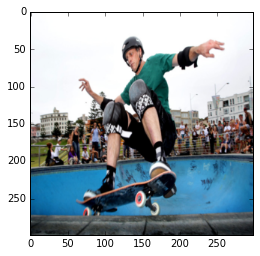

In [ ]:
plt.imshow(img)

In [ ]:
for i in range(10):
    print(' '.join(generate_caption(img_array, t=5.)[1:-1]))

a man riding a skateboard on a skateboard .
a man on a skateboard on a skateboard .
a man on a skateboard on a skateboard .
a man on a skateboard on a skateboard .
a man on a skateboard on a skateboard .
a man on a skateboard on a skateboard on a skateboard .
a man on a skateboard on a skateboard .
a man with a skateboard on a skateboard .
a man riding a skateboard on a skateboard .
a man riding a skateboard on a skateboard .


### 5. Demo

In [ ]:

def demonstrate_captions_on_images(data_folder='data2', num_images=10):

    # список всех jpg файлов в папке data
    image_files = glob.glob(os.path.join(data_folder, '*.jpg'))
    #print(type(image_files))
    # Функция для предобработки изображения
    def preprocess_image(image_path, target_size=(299, 299)):
        img = Image.open(image_path).convert('RGB')
        img = img.resize(target_size, Image.LANCZOS)
        img_array = np.array(img).astype('float32') / 255.0
        return img_array


    fig, axes = plt.subplots(num_images, 1, figsize=(15, num_images*5))

    # Если axes не массив, сделать его массивом для единообразной обработки
    if num_images == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    print(f"Генерация подписей для {num_images} изображений:")

    for i, image_file in enumerate(image_files):

        try:
            img_array = preprocess_image(image_file)

            # подпись для каждого изображения
            print(' '.join(generate_caption(img_array, t=5.)[1:-1]))

            axes[i].imshow(img_array)
            axes[i].axis('off')

        except Exception as e:
            print(f"Ошибка при обработке {image_file}: {e}")
            axes[i].axis('off')



Генерация подписей для 10 изображений:
a bunch of bananas are on a table .
a man is standing in the grass with a kite .
a man in a suit and tie with a tie .
a zebra is standing in a field with a zebra .
a bus is parked on a street with a lot of people .
a small brown bear sitting on a wooden bench .
a bunch of oranges and a banana on a table .
a plate of food with a sandwich and a fork
a group of people are standing around a table .
a man wearing a black shirt and black tie .


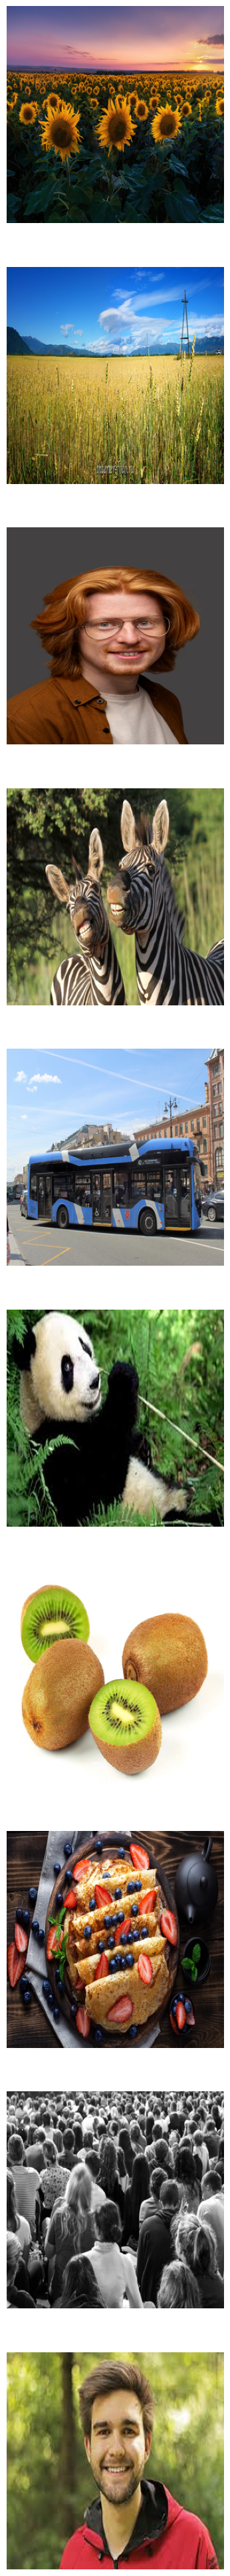

In [ ]:
demonstrate_captions_on_images()

Видно, что модель плохо распозаёт пейзажи (случай с подсолнухами и лугом) и в некоторых случаях цвета и формы объектов (как в примере с пандой или киви)